In [7]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import squarify #Mapa de árvore para o seaborn
dengue = pd.read_csv('dengbr22.csv')

C:\Users\Lua.LUADESKTOP\AppData\Local\Temp\ipykernel_13932\4223290073.py:6: DtypeWarning: Columns (44,46,54,101) have mixed types. Specify dtype option on import or set low_memory=False.
  dengue = pd.read_csv('dengbr22.csv')


In [8]:
dengue.columns

Index(['TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'SEM_NOT', 'NU_ANO', 'SG_UF_NOT',
       'ID_MUNICIP', 'ID_REGIONA', 'ID_UNIDADE', 'DT_SIN_PRI',
       ...
       'EVIDENCIA', 'PLAQ_MENOR', 'CON_FHD', 'COMPLICA', 'TP_SISTEMA',
       'NDUPLIC_N', 'DT_DIGITA', 'CS_FLXRET', 'FLXRECEBI', 'MIGRADO_W'],
      dtype='object', length=121)

<b>Registros por meses</b>: Estudo de contagem de quantas vezes o mês de notificação é registrado, baseado na contagem total de UF. 

In [9]:
dengue['ID_MUNICIP'].value_counts()

ID_MUNICIP
172100    12145
110004     2193
110020     2019
130060     1647
120020     1588
          ...  
171884        1
140050        1
160070        1
130160        1
172025        1
Name: count, Length: 356, dtype: int64

In [68]:
#Importar dados do IBGE Municípios
municipios = pd.read_excel('IBGE_MUNICIPIOS.xlsx')

In [69]:
municipios = municipios[['Código_Município','Nome_Município']]

In [70]:
#Tranformação da coluna para string, manipulando os dados
municipios['Código_Município'] = municipios['Código_Município'].astype(str)

# Remover o último dígito de cada valor na coluna 'Código_Município'
municipios['Código_Município'] = municipios['Código_Município'].str[:-1]
municipios['Código_Município']

0       110001
1       110037
2       110040
3       110034
4       110002
         ...  
5565    522200
5566    522205
5567    522220
5568    522230
5569    530010
Name: Código_Município, Length: 5570, dtype: object

In [71]:
municipios['Código_Município'] = municipios['Código_Município'].astype('Int64')

In [72]:
id_municipio_dengue = dengue['ID_MUNICIP']

In [73]:
# Realiza o merge dos dois DataFrames com base nos códigos dos municípios
nome_municipios = pd.merge(id_municipio_dengue, municipios, left_on='ID_MUNICIP', right_on='Código_Município', how='left')
print(nome_municipios)

       ID_MUNICIP  Código_Município        Nome_Município
0          120020            120020       Cruzeiro do Sul
1          120020            120020       Cruzeiro do Sul
2          120020            120020       Cruzeiro do Sul
3          120020            120020       Cruzeiro do Sul
4          120020            120020       Cruzeiro do Sul
...           ...               ...                   ...
50138      171610            171610  Paraíso do Tocantins
50139      170820            170820   Formoso do Araguaia
50140      171820            171820        Porto Nacional
50141      171070            171070            Itaguatins
50142      171840            171840    Presidente Kennedy

[50143 rows x 3 columns]


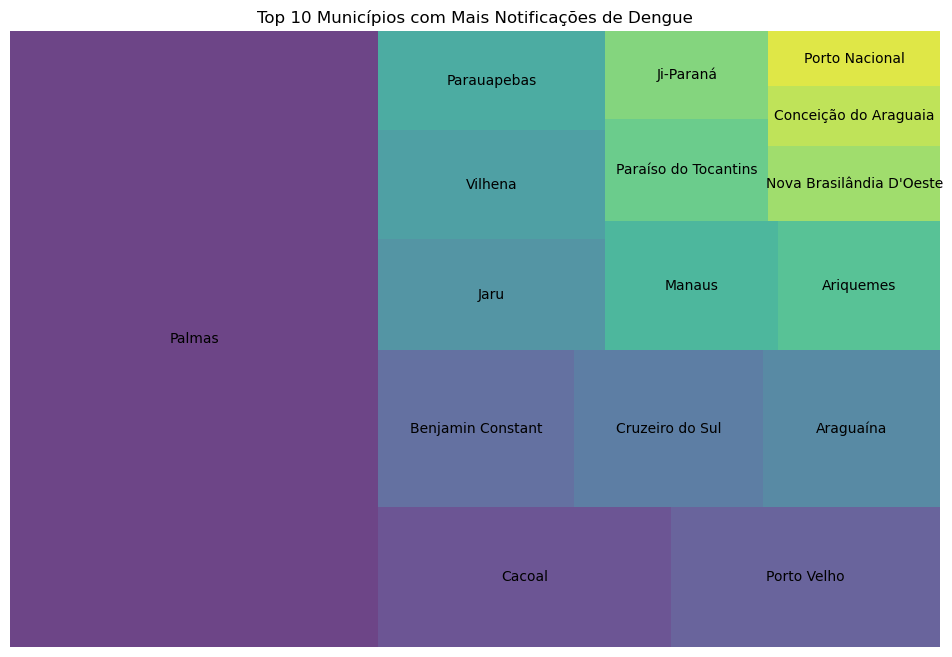

In [74]:
municipios_nomes = nome_municipios.groupby('Nome_Município').size().reset_index(name='Contagem')

# Ordenar os municípios pela contagem de notificações em ordem decrescente
municipios_nomes = municipios_nomes.sort_values(by='Contagem', ascending=False)

nome_15_municipios = municipios_nomes.head(16)

#Plotagem do gráfico de mapa de árvore
plt.figure(figsize=(12, 8))
squarify.plot(
    sizes=nome_15_municipios['Contagem'],
    label=nome_15_municipios['Nome_Município'],
    color=sns.color_palette('viridis', len(nome_15_municipios)),
    alpha=0.8
)

plt.title('Top 10 Municípios com Mais Notificações de Dengue')
plt.axis('off')  # Remove os eixos
plt.show()

In [80]:
# Se necessário, adicionar formatação para transformar em data (yyyyMMdd)
dengue['DT_NOTIFIC'] = pd.to_datetime(dengue['DT_NOTIFIC'])

# Extrair o mês e o ano da notificação
dengue['Mês'] = dengue['DT_NOTIFIC'].dt.to_period('M')

In [75]:
dengue['SG_UF_NOT'].value_counts()

SG_UF_NOT
17    20846
11    14252
15     5912
13     5356
12     3425
16      290
14       62
Name: count, dtype: int64

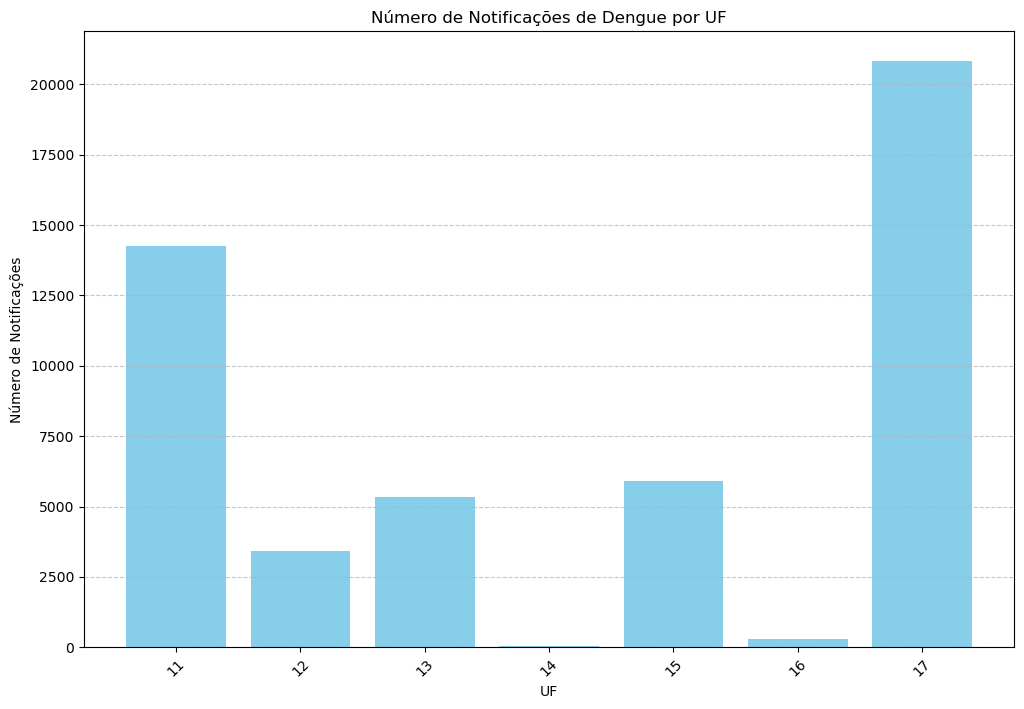

In [76]:
uf_contagem = dengue['SG_UF_NOT'].value_counts().reset_index()
uf_contagem.columns = ['UF', 'Notificacoes']

# Plotar o gráfico de barras
plt.figure(figsize=(12, 8))
plt.bar(uf_contagem['UF'], uf_contagem['Notificacoes'], color='skyblue')
plt.title('Número de Notificações de Dengue por UF')
plt.xlabel('UF')
plt.ylabel('Número de Notificações')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

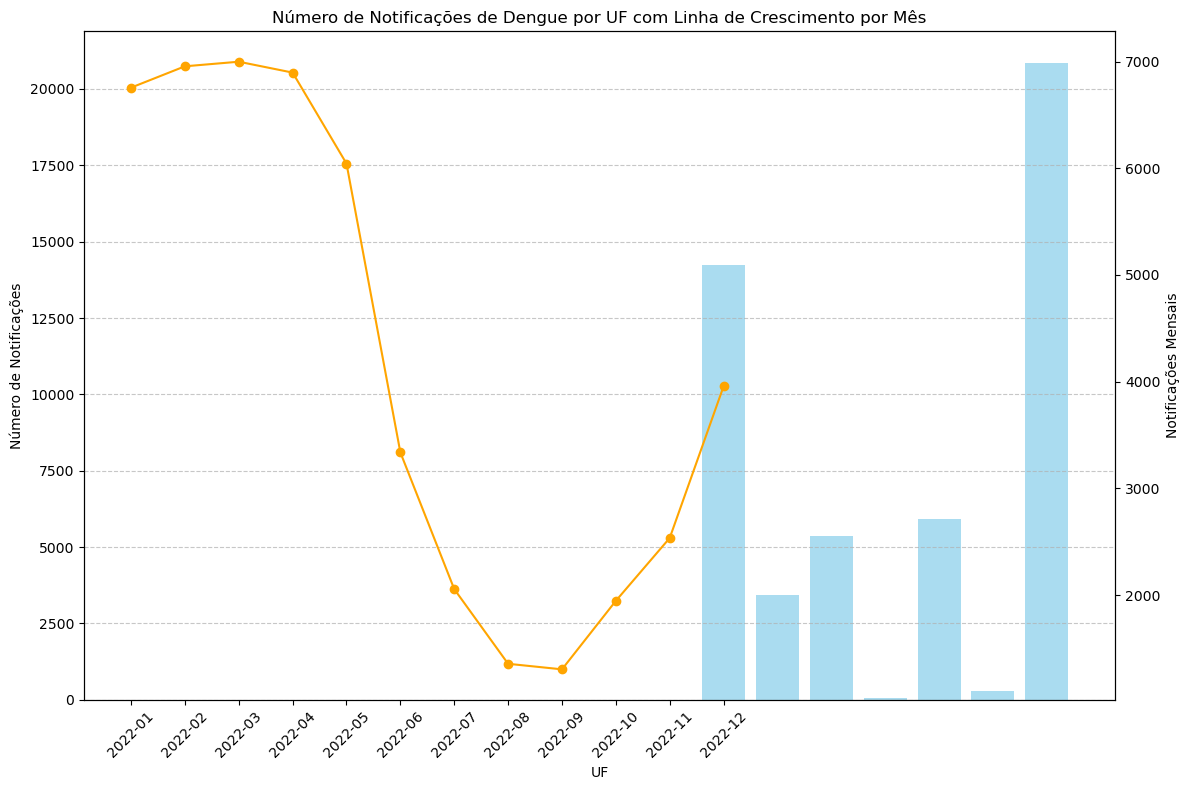

In [77]:
uf_contagem = dengue['SG_UF_NOT'].value_counts().reset_index()
uf_contagem.columns = ['UF', 'Notificacoes']

dengue['dengue_notifi_mes'] = pd.to_datetime(dengue['DT_NOTIFIC']).dt.to_period('M')  #Extrair mês

contagem_mes = dengue.groupby('dengue_notifi_mes').size().reset_index(name='Notificacoes')

# Gráfico de barras para as notificações por UF
fig, ax1 = plt.subplots(figsize=(12, 8))

ax1.bar(uf_contagem['UF'], uf_contagem['Notificacoes'], color='skyblue', alpha=0.7)
ax1.set_xlabel('UF')
ax1.set_ylabel('Número de Notificações')
ax1.set_title('Número de Notificações de Dengue por UF com Linha de Crescimento por Mês')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)

# Criar um segundo eixo Y para a linha de crescimento
ax2 = ax1.twinx()
ax2.plot(contagem_mes['dengue_notifi_mes'].astype(str), contagem_mes['Notificacoes'], color='orange', marker='o', linestyle='-')
ax2.set_ylabel('Notificações Mensais')

# Melhorar o layout
fig.tight_layout()
plt.show()

In [78]:
dengue['DT_SIN_PRI'] #Data do primeiro sintoma
dengue['DT_SIN_PRI'] = pd.to_datetime(dengue['DT_SIN_PRI'])

dengue['dengue_sin_mes'] = pd.to_datetime(dengue['DT_SIN_PRI']).dt.to_period('M')  #Extrair mês
dengue['dengue_sin_mes']

sin_por_uf = dengue.groupby('dengue_sin_mes')['SG_UF_NOT'].sum().reset_index()

NameError: name 'notifi_por_uf' is not defined

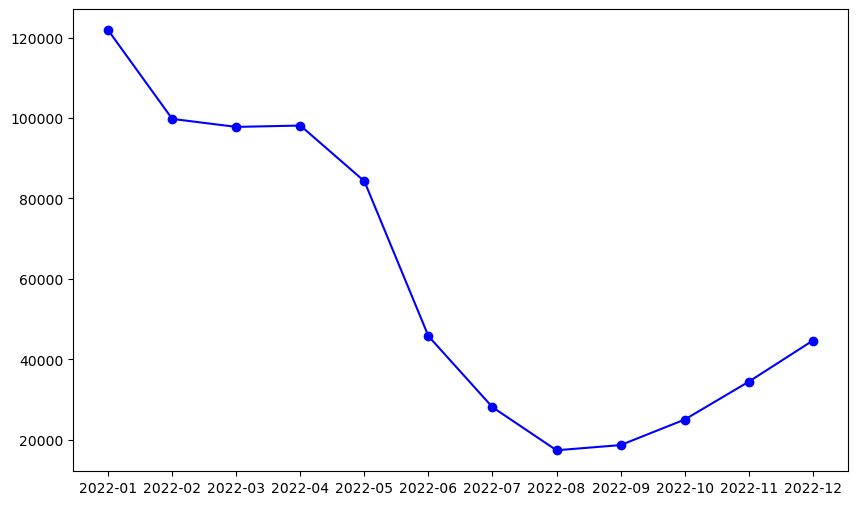

In [79]:
# Criar uma figura e os eixos
plt.figure(figsize=(10, 6))

# Plotar a primeira linha para sintomas registrados por UF
plt.plot(sin_por_uf['dengue_sin_mes'].astype(str), sin_por_uf['SG_UF_NOT'], 
         marker='o', linestyle='-', color='blue', label='Sintomas')

# Plotar a segunda linha para notificações por UF
plt.plot(notifi_por_uf['dengue_notifi_mes'].astype(str), notifi_por_uf['SG_UF_NOT'], 
         marker='o', linestyle='-', color='red', label='Notificações')

# Título e labels dos eixos
plt.title('Contagem de Sintomas e Notificações Registrados por UF')
plt.xlabel('Mês')
plt.ylabel('Quantidade')
plt.xticks(rotation=45) # Rotacionar os rótulos do eixo X para melhor visualização
plt.grid(True) # Adicionar a grade
plt.legend() # Adicionar a legenda para identificar as linhas
plt.show() # Mostrar o gráfico

In [ ]:
# Calcular a diferença entre as dias das datas de notificação e as datas dos sintomas
dengue['diferenca_dias'] = (dengue['DT_NOTIFIC'] - dengue['DT_SIN_PRI']).dt.days

# Ordenar o DataFrame pela coluna 'diferenca_dias' em ordem decrescente
dengue_ordenado = dengue.sort_values(by='diferenca_dias', ascending=False)
resultado_dias = dengue_ordenado[['DT_NOTIFIC', 'DT_SIN_PRI', 'diferenca_dias']]
resultado_dias.head(30)

,DT_NOTIFIC,DT_SIN_PRI,diferenca_dias
19530,2022-12-23,2022-01-16,341.0
24039,2022-12-27,2022-01-27,334.0
4984,2022-12-06,2022-01-29,311.0
19928,2022-11-29,2022-01-26,307.0
14545,2022-12-16,2022-02-12,307.0
19705,2022-11-04,2022-01-02,306.0
19173,2022-12-07,2022-02-05,305.0
14666,2022-12-19,2022-03-05,289.0
29189,2022-12-23,2022-03-20,278.0
27801,2022-12-03,2022-03-02,276.0


In [ ]:
resultado_dias.describe() #Conjunto de dados estatísticos

,DT_NOTIFIC,DT_SIN_PRI,diferenca_dias
count,50143,50141,50141.000000
mean,2022-05-17 01:12:01.464611328,2022-05-12 15:45:06.838714624,4.393750
min,2022-01-02 00:00:00,2022-01-02 00:00:00,0.000000
25%,2022-02-23 00:00:00,2022-02-18 00:00:00,2.000000
50%,2022-04-20 00:00:00,2022-04-15 00:00:00,3.000000
75%,2022-07-08 00:00:00,2022-07-04 00:00:00,5.000000
max,2022-12-31 00:00:00,2022-12-31 00:00:00,341.000000
std,NaN,NaN,8.019249


In [ ]:
dengue['DT_INVEST'] #Data de investigação

0        2022-01-12
1        2022-08-11
2        2022-03-25
3        2022-03-07
4        2022-01-18
            ...    
50138    2022-10-13
50139    2022-01-24
50140    2022-10-21
50141    2022-10-20
50142    2022-11-03
Name: DT_INVEST, Length: 50143, dtype: object

In [ ]:
dengue['DT_ENCERRA'] #Informar a data do encerramento do caso

0        2022-01-17
1        2022-10-11
2        2022-03-31
3        2022-03-23
4        2022-01-26
            ...    
50138    2022-11-18
50139    2022-03-03
50140    2022-11-21
50141    2022-11-07
50142    2023-01-03
Name: DT_ENCERRA, Length: 50143, dtype: object

In [ ]:
dengue['ID_MUNICIP'].value_counts()

ID_MUNICIP
172100    12145
110004     2193
110020     2019
130060     1647
120020     1588
          ...  
171884        1
140050        1
160070        1
130160        1
172025        1
Name: count, Length: 356, dtype: int64